## 🔍 VÒNG 3: CUSTOMER PATTERN MINING — Phân tích Khách Đặc biệt

**Mục tiêu:**
- **Chuẩn hoá tên** khách từ cột `notes` bằng Vietnamese normalization + fuzzy grouping (rule-based)
- **Gom nhóm** ~5–8 khách quen từ 101 dòng ghi chú với nhiều cách viết sai lỗi khác nhau
- **Phân tích hành vi** từng khách: tần suất, giá trị đơn, tỷ lệ thanh toán
- **Phát hiện bất thường** trong các đơn có ghi chú: đơn giá trị cao bất thường, đơn thanh toán lệch chiều thói quen

**Input:** `data/DetailsTransaction.csv`  
**Output:** `data/Customer_Pattern.csv`

---
> **Lý do không dùng PhoBERT:** 101 samples không đủ để fine-tune embedding model. Dữ liệu thực tế là tên riêng viết tắt kiểu chat ("ngoc pt", "c hai") — hoàn toàn nằm ngoài vocabulary PhoBERT. Approach tối ưu: normalization Unicode + Levenshtein similarity + manual grouping rule ngắn.


## 0. Import & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import unicodedata
import re
import warnings
from difflib import SequenceMatcher

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

# Màu nhóm khách cố định
CUSTOMER_COLORS = {
    'ngoc_pt':      '#e74c3c',
    'c_hai':        '#3498db',
    'c_trang':      '#9b59b6',
    'ong_chu_sh':   '#f39c12',
    'ban_chu_tho':  '#1abc9c',
    'other':        '#95a5a6',
}

CUSTOMER_LABELS = {
    'ngoc_pt':   'Ngọc PT',
    'c_hai':     'C Hải',
    'c_trang':   'C Trang',
    'ong_chu_sh':'Ông Chú SH',
    'ban_chu_tho':'Bạn Chú Thọ',
    'other':     'Khác / 1 lần',
}

def fmt_k(x, _=None):
    return f'{x/1e3:.0f}k'

print("✅ Đã load thư viện thành công.")


✅ Đã load thư viện thành công.


## 1. Load Data & Tổng quan Notes

In [2]:
df_details = pd.read_csv('./data/DetailsTransaction.csv')
df_details['transaction_at'] = pd.to_datetime(df_details['transaction_at'])
df_details = df_details.sort_values('transaction_at').reset_index(drop=True)

notes_total  = len(df_details)
notes_filled = df_details['notes'].notna().sum()
print(f"Tổng số hóa đơn: {notes_total:,}")
print(f"Hóa đơn có ghi chú: {notes_filled} ({notes_filled/notes_total:.1%})")
print(f"\nKhoảng thời gian dữ liệu: {df_details['transaction_at'].min().date()} → {df_details['transaction_at'].max().date()}")
print(f"\nMẫu ghi chú thô (15 dòng đầu):")
display(df_details[df_details['notes'].notna()][['transaction_at','total_revenue','cash_payment','transfer_payment','notes']].head(15))


Tổng số hóa đơn: 5,412
Hóa đơn có ghi chú: 101 (1.9%)

Khoảng thời gian dữ liệu: 2025-12-20 → 2026-04-30

Mẫu ghi chú thô (15 dòng đầu):


,transaction_at,total_revenue,cash_payment,transfer_payment,notes
258,2025-12-25 16:31:08,38000,0,38000,ngoc pt
295,2025-12-26 14:35:27,46000,0,46000,ngoc pt
337,2025-12-27 14:48:01,19000,19000,0,ngoc pt
345,2025-12-27 17:03:34,52000,52000,0,ong chu SH
400,2025-12-29 13:47:16,19000,0,19000,c hai
401,2025-12-29 13:48:38,22000,22000,0,c hai
518,2026-01-01 08:41:30,284000,0,284000,c hai
571,2026-01-02 14:30:59,46000,0,46000,ngoc pt
677,2026-01-05 10:06:01,522000,0,522000,c trang
880,2026-01-09 12:00:28,22000,22000,0,Coca của Jimmy


---
## 2. Chuẩn hoá Tên — Vietnamese Normalization + Fuzzy Grouping

**Pipeline chuẩn hoá:**
1. `lowercase` → `strip` → loại ký tự đặc biệt
2. `NFD normalize` → xoá combining diacritics (bỏ dấu tiếng Việt)
3. Collapse whitespace
4. Map vào nhóm khách bằng bảng rule-based (Levenshtein-informed)

**Tại sao rule-based thay vì pure clustering?**  
Với 101 samples, distance matrix 33×33 rất thưa và noise cao. Cách tiếp cận hybrid — normalize + similarity check + domain judgment — cho kết quả đúng hơn và giải thích được cho chủ quán.


In [3]:
# ── Step 1: Normalize ──────────────────────────────────────────────────────
def normalize_name(s):
    """Chuẩn hoá tên: lowercase, bỏ dấu, loại ký tự đặc biệt, collapse spaces"""
    if pd.isna(s):
        return None
    s = str(s).strip().lower()
    # Bỏ dấu tiếng Việt qua NFD decomposition
    s = unicodedata.normalize('NFD', s)
    s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')
    # Giữ lại chữ cái, số, khoảng trắng
    s = re.sub(r'[^a-z0-9 ]', '', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def similarity(a, b):
    """Levenshtein-based similarity score (0–1)"""
    return SequenceMatcher(None, a, b).ratio()

# Áp dụng normalize
notes_df = df_details[df_details['notes'].notna()].copy()
notes_df['norm_note'] = notes_df['notes'].apply(normalize_name)

print("Unique normalized values:")
for v in sorted(notes_df['norm_note'].unique()):
    print(f"  '{v}'")
print(f"\nTổng: {notes_df['norm_note'].nunique()} variant → sẽ gom thành nhóm")


Unique normalized values:
  'a hai'
  'a noc'
  'a trang'
  'at'
  'ban anh dung'
  'ban chu tho neu chu quen thi chu quan nhac chu'
  'bao ve'
  'bo an hai'
  'c ai'
  'c hai'
  'c trang'
  'c trang 20k tien mat muon'
  'c tranng'
  'chu hai'
  'chu hair'
  'chu trang'
  'coca cua jimmy'
  'hoang anh'
  'n9'
  'n9oc'
  'n9oc nu'
  'n9oc nu pt'
  'n9oc pt'
  'nghia'
  'ngoc'
  'ngoc nu pt'
  'ngoc pt'
  'ngoccpt'
  'ngocpt'
  'noc pt'
  'nogc pt'
  'ong chu sh'
  'tung tung tung sahur'

Tổng: 33 variant → sẽ gom thành nhóm


In [4]:
# ── Step 2: Similarity Matrix để xác nhận nhóm ──────────────────────────
unique_notes = sorted(notes_df['norm_note'].unique())
n = len(unique_notes)
sim_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = similarity(unique_notes[i], unique_notes[j])

sim_df = pd.DataFrame(sim_matrix, index=unique_notes, columns=unique_notes)

# Hiện top pairs có similarity cao (mà không phải cùng string)
pairs = []
for i in range(n):
    for j in range(i+1, n):
        if sim_matrix[i,j] > 0.55:
            pairs.append((unique_notes[i], unique_notes[j], round(sim_matrix[i,j], 3)))

pairs_df = pd.DataFrame(pairs, columns=['name_a', 'name_b', 'similarity']).sort_values('similarity', ascending=False)
print("Top cặp tên tương đồng cao (similarity > 0.55):")
display(pairs_df.head(25))


Top cặp tên tương đồng cao (similarity > 0.55):


,name_a,name_b,similarity
18,c trang,c tranng,0.933
21,chu hai,chu hair,0.933
64,ngoc pt,noc pt,0.923
50,n9oc pt,noc pt,0.923
71,noc pt,nogc pt,0.923
66,ngoccpt,ngocpt,0.923
63,ngoc pt,ngocpt,0.923
40,n9oc nu pt,ngoc nu pt,0.900
13,c ai,c hai,0.889
19,c trang,chu trang,0.875


In [5]:
# ── Step 3: Rule-Based Grouping Map ─────────────────────────────────────
# Kết hợp similarity matrix + domain knowledge về cách đặt tên trong quán
# "n9oc" = "ngoc" (gõ số 9 thay chữ "g"), "c hai" = "chú hải" (viết tắt) v.v.

GROUP_MAP = {
    # === NHÓM NGỌC PT — 57 lần xuất hiện ===
    # Cốt lõi: "ngoc pt" với nhiều lỗi gõ phím + viết tắt
    'ngoc pt'    : 'ngoc_pt',
    'n9oc pt'    : 'ngoc_pt',   # 9 thay g — lỗi gõ điện thoại phổ biến
    'n9oc'       : 'ngoc_pt',
    'n9oc nu'    : 'ngoc_pt',
    'n9oc nu pt' : 'ngoc_pt',
    'ngoc nu pt' : 'ngoc_pt',   # "nữ PT" — phân biệt với người khác tên Ngọc
    'ngoccpt'    : 'ngoc_pt',   # thiếu dấu cách
    'ngocpt'     : 'ngoc_pt',
    'noc pt'     : 'ngoc_pt',   # bỏ sót chữ g
    'nogc pt'    : 'ngoc_pt',   # hoán vị gc
    'ngoc'       : 'ngoc_pt',   # chỉ tên không có PT
    'a noc'      : 'ngoc_pt',   # "a" = anh/chị, "noc" ≈ "ngoc"
    'n9'         : 'ngoc_pt',   # viết tắt tối giản

    # === NHÓM C HẢI — 25 lần xuất hiện ===
    # "c" = chú/cô/anh, "hai" = Hải
    'c hai'      : 'c_hai',
    'a hai'      : 'c_hai',     # "a" = anh
    'chu hai'    : 'c_hai',
    'c ai'       : 'c_hai',     # lỗi gõ "h" → "": 'c hai' → 'c ai'
    'bo an hai'  : 'c_hai',     # "bố anh Hải" — người thân của C Hải
    'chu hair'   : 'c_hai',     # lỗi thêm 'r' ở cuối

    # === NHÓM C TRANG — 9 lần xuất hiện ===
    'c trang'    : 'c_trang',
    'a trang'    : 'c_trang',
    'c tranng'   : 'c_trang',   # gõ thừa 'n'
    'chu trang'  : 'c_trang',
    'c trang 20k tien mat muon': 'c_trang',  # có ghi chú đặc biệt về mượn tiền

    # === NHÓM ÔNG CHỦ SH — 1 lần ===
    'ong chu sh' : 'ong_chu_sh',

    # === NHÓM BẠN CHÚ THỌ — 2 lần ===
    'ban chu tho neu chu quen thi chu quan nhac chu': 'ban_chu_tho',

    # === KHÁC / 1 LẦN ===
    'coca cua jimmy'  : 'other',
    'tung tung tung sahur': 'other',
    'nghia'           : 'other',
    'hoang anh'       : 'other',
    'bao ve'          : 'other',
    'ban anh dung'    : 'other',
    'at'              : 'other',
}

notes_df['customer_group'] = notes_df['norm_note'].map(GROUP_MAP).fillna('other')

print("Phân bổ theo nhóm khách:")
gc = notes_df['customer_group'].value_counts()
for grp, cnt in gc.items():
    label = CUSTOMER_LABELS.get(grp, grp)
    print(f"  {label:20s}: {cnt:3d} đơn")


Phân bổ theo nhóm khách:
  Ngọc PT             :  57 đơn
  C Hải               :  25 đơn
  C Trang             :   9 đơn
  Khác / 1 lần        :   7 đơn
  Bạn Chú Thọ         :   2 đơn
  Ông Chú SH          :   1 đơn


---
## 3. Hồ Sơ Hành Vi Từng Khách

In [6]:
# ── Tính profile từng nhóm ───────────────────────────────────────────────
profile = notes_df.groupby('customer_group').agg(
    so_don         = ('total_revenue', 'count'),
    doanh_thu_tong = ('total_revenue', 'sum'),
    don_tb         = ('total_revenue', 'mean'),
    don_max        = ('total_revenue', 'max'),
    don_min        = ('total_revenue', 'min'),
    don_std        = ('total_revenue', 'std'),
    transfer_sum   = ('transfer_payment', 'sum'),
    cash_sum       = ('cash_payment', 'sum'),
    first_seen     = ('transaction_at', 'min'),
    last_seen      = ('transaction_at', 'max'),
).reset_index()

profile['pct_transfer'] = (
    profile['transfer_sum'] / (profile['transfer_sum'] + profile['cash_sum']) * 100
).round(1).fillna(0)

profile['don_tb']          = profile['don_tb'].round(0)
profile['doanh_thu_tong']  = profile['doanh_thu_tong'].round(0)
profile['don_std']         = profile['don_std'].round(0).fillna(0)
profile['label']           = profile['customer_group'].map(CUSTOMER_LABELS)

# Sắp xếp theo số đơn
profile = profile.sort_values('so_don', ascending=False).reset_index(drop=True)

display_cols = ['label','so_don','don_tb','don_max','doanh_thu_tong','pct_transfer','first_seen','last_seen']
display(profile[display_cols].rename(columns={
    'label': 'Khách',
    'so_don': 'Số đơn',
    'don_tb': 'ĐTB (đ)',
    'don_max': 'Đơn max (đ)',
    'doanh_thu_tong': 'Tổng DT (đ)',
    'pct_transfer': '% CK',
    'first_seen': 'Lần đầu',
    'last_seen': 'Lần cuối',
}))


,Khách,Số đơn,ĐTB (đ),Đơn max (đ),Tổng DT (đ),% CK,Lần đầu,Lần cuối
0,Ngọc PT,57,31000.0,85000,1767000,90.0,2025-12-25 16:31:08,2026-04-29 15:22:39
1,C Hải,25,87080.0,284000,2177000,36.9,2025-12-29 13:47:16,2026-04-29 08:51:39
2,C Trang,9,383111.0,625000,3448000,92.2,2026-01-05 10:06:01,2026-04-30 10:23:55
3,Khác / 1 lần,7,24857.0,45000,174000,61.5,2026-01-09 12:00:28,2026-03-28 08:59:36
4,Bạn Chú Thọ,2,52000.0,85000,104000,0.0,2026-01-09 15:56:01,2026-01-10 16:07:59
5,Ông Chú SH,1,52000.0,52000,52000,0.0,2025-12-27 17:03:34,2025-12-27 17:03:34


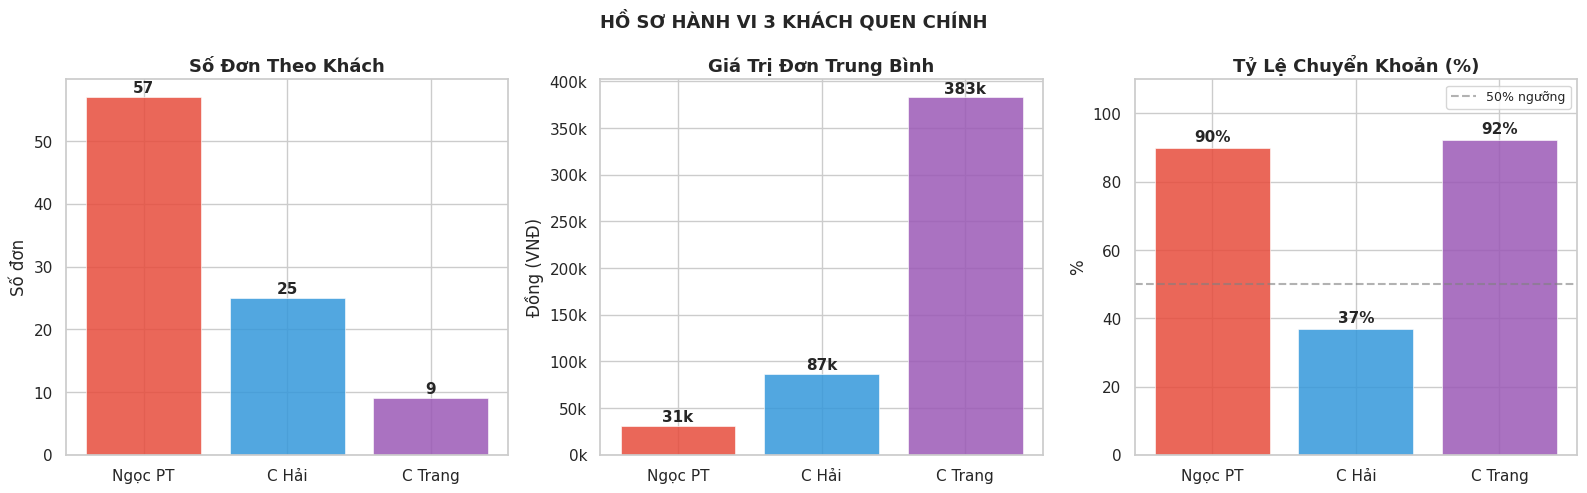

In [7]:
# ── Visualize: Hồ sơ từng khách ──────────────────────────────────────────
top3 = profile[profile['customer_group'].isin(['ngoc_pt', 'c_hai', 'c_trang'])]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Số đơn
ax = axes[0]
colors = [CUSTOMER_COLORS.get(g, '#95a5a6') for g in top3['customer_group']]
bars = ax.bar(top3['label'], top3['so_don'], color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_title('Số Đơn Theo Khách')
ax.set_ylabel('Số đơn')
for bar, v in zip(bars, top3['so_don']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(v), ha='center', va='bottom', fontweight='bold')

# Plot 2: Giá trị đơn trung bình
ax = axes[1]
bars = ax.bar(top3['label'], top3['don_tb'], color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_title('Giá Trị Đơn Trung Bình')
ax.set_ylabel('Đồng (VNĐ)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
for bar, v in zip(bars, top3['don_tb']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{v/1e3:.0f}k', ha='center', va='bottom', fontweight='bold')

# Plot 3: % Chuyển khoản
ax = axes[2]
bars = ax.bar(top3['label'], top3['pct_transfer'], color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axhline(50, color='gray', linestyle='--', alpha=0.6, label='50% ngưỡng')
ax.set_title('Tỷ Lệ Chuyển Khoản (%)')
ax.set_ylabel('%')
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
for bar, v in zip(bars, top3['pct_transfer']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{v:.0f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('HỒ SƠ HÀNH VI 3 KHÁCH QUEN CHÍNH', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


---
## 4. Phân tích Chi tiết Từng Khách

In [8]:
# ── NGỌC PT ──────────────────────────────────────────────────────────────
ngoc = notes_df[notes_df['customer_group'] == 'ngoc_pt'].copy()
ngoc = ngoc.sort_values('transaction_at')

print("=" * 60)
print(f"👤 NGỌC PT — {len(ngoc)} đơn")
print("=" * 60)
print(f"  Tần suất: {len(ngoc)} lần từ {ngoc['transaction_at'].min().date()} đến {ngoc['transaction_at'].max().date()}")
print(f"  Đơn TB:   {ngoc['total_revenue'].mean():.0f} đ")
print(f"  % CK:     {ngoc['transfer_payment'].sum() / ngoc['total_revenue'].sum() * 100:.1f}%")
print(f"  Các cách ghi tên: {', '.join(sorted(ngoc['notes'].unique())[:8])}...")

print(f"\n  ⚠️  Đơn dùng TIỀN MẶT ({(ngoc['cash_payment'] > 0).sum()} lần):")
cash_ngoc = ngoc[ngoc['cash_payment'] > 0][['transaction_at','total_revenue','cash_payment','notes']]
display(cash_ngoc)

print(f"\n  ⚠️  Đơn giá trị CAO BẤT THƯỜNG (> 2× giá TB):")
high_ngoc = ngoc[ngoc['total_revenue'] > ngoc['total_revenue'].mean() * 2]
if len(high_ngoc):
    display(high_ngoc[['transaction_at','total_revenue','transfer_payment','cash_payment','notes']])
else:
    print("  Không có đơn bất thường.")


👤 NGỌC PT — 57 đơn
  Tần suất: 57 lần từ 2025-12-25 đến 2026-04-29
  Đơn TB:   31000 đ
  % CK:     90.0%
  Các cách ghi tên: N9oc nữ, N9oc pt, Ngoc, Ngoc pt, Ngọc nữ PT, Ngọc pt, Nọc pt, a Noc...

  ⚠️  Đơn dùng TIỀN MẶT (9 lần):


,transaction_at,total_revenue,cash_payment,notes
337,2025-12-27 14:48:01,19000,19000,ngoc pt
929,2026-01-10 13:15:06,19000,19000,ngoc pt
2066,2026-02-04 11:07:54,19000,19000,Ngọc pt
2233,2026-02-08 13:53:14,19000,19000,a Noc
3057,2026-03-06 16:28:45,20000,20000,ngoc pt
3099,2026-03-07 17:04:15,20000,20000,ngoc pt
3294,2026-03-11 16:38:31,20000,20000,noc pt
3413,2026-03-13 16:42:51,20000,20000,ngoc pt
4629,2026-04-10 16:07:41,20000,20000,ngocpt



  ⚠️  Đơn giá trị CAO BẤT THƯỜNG (> 2× giá TB):


,transaction_at,total_revenue,transfer_payment,cash_payment,notes
5244,2026-04-25 18:02:05,85000,85000,0,ngoc pt


In [9]:
# ── C HẢI ────────────────────────────────────────────────────────────────
chai = notes_df[notes_df['customer_group'] == 'c_hai'].copy()
chai = chai.sort_values('transaction_at')

print("=" * 60)
print(f"👤 C HẢI — {len(chai)} đơn")
print("=" * 60)
print(f"  Tần suất: {len(chai)} lần từ {chai['transaction_at'].min().date()} đến {chai['transaction_at'].max().date()}")
print(f"  Đơn TB:   {chai['total_revenue'].mean():.0f} đ")
print(f"  % CK:     {chai['transfer_payment'].sum() / chai['total_revenue'].sum() * 100:.1f}%")
print(f"  Phần lớn trả TIỀN MẶT: {(chai['cash_payment'] > 0).sum()}/{len(chai)} đơn ({(chai['cash_payment'] > 0).sum()/len(chai)*100:.0f}%)")

print(f"\n  📊 Phân bổ giá trị đơn:")
print(chai['total_revenue'].describe().apply(lambda x: f'{x:,.0f}').to_string())

print(f"\n  ⚠️  Đơn CK bất thường (khách quen tiền mặt nhưng đột ngột CK):")
ck_chai = chai[chai['transfer_payment'] > 0][['transaction_at','total_revenue','transfer_payment','cash_payment','notes']]
if len(ck_chai):
    display(ck_chai)
else:
    print("  Không có.")

print(f"\n  ⚠️  Đơn giá trị CAO BẤT THƯỜNG (top 20%):")
p80 = chai['total_revenue'].quantile(0.80)
high_chai = chai[chai['total_revenue'] >= p80].sort_values('total_revenue', ascending=False)
display(high_chai[['transaction_at','total_revenue','cash_payment','transfer_payment','notes']].head(8))


👤 C HẢI — 25 đơn
  Tần suất: 25 lần từ 2025-12-29 đến 2026-04-29
  Đơn TB:   87080 đ
  % CK:     36.9%
  Phần lớn trả TIỀN MẶT: 17/25 đơn (68%)

  📊 Phân bổ giá trị đơn:
count         25
mean      87,080
std       75,689
min       19,000
25%       24,000
50%       62,000
75%      127,000
max      284,000

  ⚠️  Đơn CK bất thường (khách quen tiền mặt nhưng đột ngột CK):


,transaction_at,total_revenue,transfer_payment,cash_payment,notes
400,2025-12-29 13:47:16,19000,19000,0,c hai
518,2026-01-01 08:41:30,284000,284000,0,c hai
1865,2026-01-31 09:12:09,44000,44000,0,C HAI
2225,2026-02-08 10:54:25,127000,127000,0,A Hải
2548,2026-02-23 10:12:35,20000,20000,0,A Hai
2750,2026-02-28 17:14:24,20000,20000,0,a hai
3412,2026-03-13 16:39:23,48000,48000,0,bố an hai
3441,2026-03-14 10:59:47,241000,241000,0,chú Hải



  ⚠️  Đơn giá trị CAO BẤT THƯỜNG (top 20%):


,transaction_at,total_revenue,cash_payment,transfer_payment,notes
518,2026-01-01 08:41:30,284000,0,284000,c hai
3441,2026-03-14 10:59:47,241000,0,241000,chú Hải
3756,2026-03-21 08:36:12,207000,207000,0,c hai
2916,2026-03-04 08:41:00,195000,195000,0,c ai
4064,2026-03-29 07:56:57,137000,137000,0,chú Hair


In [10]:
# ── C TRANG ───────────────────────────────────────────────────────────────
ctrang = notes_df[notes_df['customer_group'] == 'c_trang'].copy()
ctrang = ctrang.sort_values('transaction_at')

print("=" * 60)
print(f"👤 C TRANG — {len(ctrang)} đơn")
print("=" * 60)
print(f"  Tần suất: {len(ctrang)} lần từ {ctrang['transaction_at'].min().date()} đến {ctrang['transaction_at'].max().date()}")
print(f"  Đơn TB:   {ctrang['total_revenue'].mean():.0f} đ")
print(f"  Đơn lớn nhất: {ctrang['total_revenue'].max():,.0f} đ")
print(f"  % CK:     {ctrang['transfer_payment'].sum() / ctrang['total_revenue'].sum() * 100:.1f}%")

print(f"\n  📋 Tất cả đơn của C Trang:")
display(ctrang[['transaction_at','total_revenue','transfer_payment','cash_payment','notes']])

print(f"\n  ⚠️  Đơn tiền mặt (khách quen CK):")
cash_ctrang = ctrang[ctrang['cash_payment'] > 0]
if len(cash_ctrang):
    display(cash_ctrang[['transaction_at','total_revenue','cash_payment','notes']])


👤 C TRANG — 9 đơn
  Tần suất: 9 lần từ 2026-01-05 đến 2026-04-30
  Đơn TB:   383111 đ
  Đơn lớn nhất: 625,000 đ
  % CK:     92.2%

  📋 Tất cả đơn của C Trang:


,transaction_at,total_revenue,transfer_payment,cash_payment,notes
677,2026-01-05 10:06:01,522000,522000,0,c trang
943,2026-01-11 08:25:36,131000,0,131000,Chú Trang
1690,2026-01-28 08:02:54,606000,606000,0,c trang
2266,2026-02-09 11:45:10,623000,623000,0,C TRANG
2649,2026-02-26 08:32:08,137000,0,137000,a trang
2994,2026-03-05 12:59:48,46000,46000,0,c Trang
3479,2026-03-15 12:06:40,367000,367000,0,c tranng
4745,2026-04-14 08:06:36,625000,625000,0,c trang + 20k tiền mặt mượn
5399,2026-04-30 10:23:55,391000,391000,0,c trang



  ⚠️  Đơn tiền mặt (khách quen CK):


,transaction_at,total_revenue,cash_payment,notes
943,2026-01-11 08:25:36,131000,131000,Chú Trang
2649,2026-02-26 08:32:08,137000,137000,a trang


---
## 5. Phát Hiện Bất Thường (Anomaly Detection)

In [11]:
# ── Anomaly scoring dựa trên thói quen khách ────────────────────────────

anomalies = []

for grp in ['ngoc_pt', 'c_hai', 'c_trang']:
    sub = notes_df[notes_df['customer_group'] == grp].copy()
    label = CUSTOMER_LABELS[grp]

    # Thói quen thanh toán
    dominant_ck  = sub['transfer_payment'].sum() > sub['cash_payment'].sum()
    pct_ck       = sub['transfer_payment'].sum() / sub['total_revenue'].sum() * 100
    avg_rev      = sub['total_revenue'].mean()
    std_rev      = sub['total_revenue'].std() if len(sub) > 2 else avg_rev * 0.5

    for _, row in sub.iterrows():
        flags = []
        severity = 0

        # Bất thường 1: Thanh toán lệch chiều thói quen
        is_cash_txn = row['cash_payment'] > 0
        if dominant_ck and is_cash_txn:
            flags.append(f"💸 CK→Tiền mặt (khách {pct_ck:.0f}% CK thói quen)")
            severity += 2
        elif not dominant_ck and row['transfer_payment'] > 0:
            flags.append(f"💸 Tiền mặt→CK (khách {100-pct_ck:.0f}% tiền mặt thói quen)")
            severity += 1

        # Bất thường 2: Đơn giá trị cao bất thường (> avg + 2σ)
        threshold_high = avg_rev + 2 * std_rev
        if row['total_revenue'] > threshold_high:
            flags.append(f"📈 Đơn cao bất thường ({row['total_revenue']/1e3:.0f}k vs TB {avg_rev/1e3:.0f}k, ngưỡng {threshold_high/1e3:.0f}k)")
            severity += 2

        # Bất thường 3: Kết hợp giá cao + thanh toán lệch chiều (rủi ro cao nhất)
        if severity >= 3:
            severity = 5  # escalate

        if flags:
            anomalies.append({
                'khach': label,
                'ngay': row['transaction_at'].strftime('%Y-%m-%d %H:%M'),
                'doanh_thu': row['total_revenue'],
                'cash': row['cash_payment'],
                'transfer': row['transfer_payment'],
                'notes_goc': row['notes'],
                'flags': ' | '.join(flags),
                'severity': severity,
            })

anom_df = pd.DataFrame(anomalies).sort_values(['severity', 'doanh_thu'], ascending=[False, False])

print(f"📋 Tổng số đơn đáng ngờ: {len(anom_df)}")
print()
display(anom_df[['khach','ngay','doanh_thu','cash','transfer','flags','severity']].reset_index(drop=True))


📋 Tổng số đơn đáng ngờ: 21



,khach,ngay,doanh_thu,cash,transfer,flags,severity
0,C Hải,2026-01-01 08:41,284000,0,284000,💸 Tiền mặt→CK (khách 63% tiền mặt thói quen) |...,5
1,C Hải,2026-03-14 10:59,241000,0,241000,💸 Tiền mặt→CK (khách 63% tiền mặt thói quen) |...,5
2,C Trang,2026-02-26 08:32,137000,137000,0,💸 CK→Tiền mặt (khách 92% CK thói quen),2
3,C Trang,2026-01-11 08:25,131000,131000,0,💸 CK→Tiền mặt (khách 92% CK thói quen),2
4,Ngọc PT,2026-04-25 18:02,85000,0,85000,"📈 Đơn cao bất thường (85k vs TB 31k, ngưỡng 59k)",2
5,Ngọc PT,2026-04-24 16:39,60000,0,60000,"📈 Đơn cao bất thường (60k vs TB 31k, ngưỡng 59k)",2
6,Ngọc PT,2026-03-06 16:28,20000,20000,0,💸 CK→Tiền mặt (khách 90% CK thói quen),2
7,Ngọc PT,2026-03-07 17:04,20000,20000,0,💸 CK→Tiền mặt (khách 90% CK thói quen),2
8,Ngọc PT,2026-03-11 16:38,20000,20000,0,💸 CK→Tiền mặt (khách 90% CK thói quen),2
9,Ngọc PT,2026-03-13 16:42,20000,20000,0,💸 CK→Tiền mặt (khách 90% CK thói quen),2


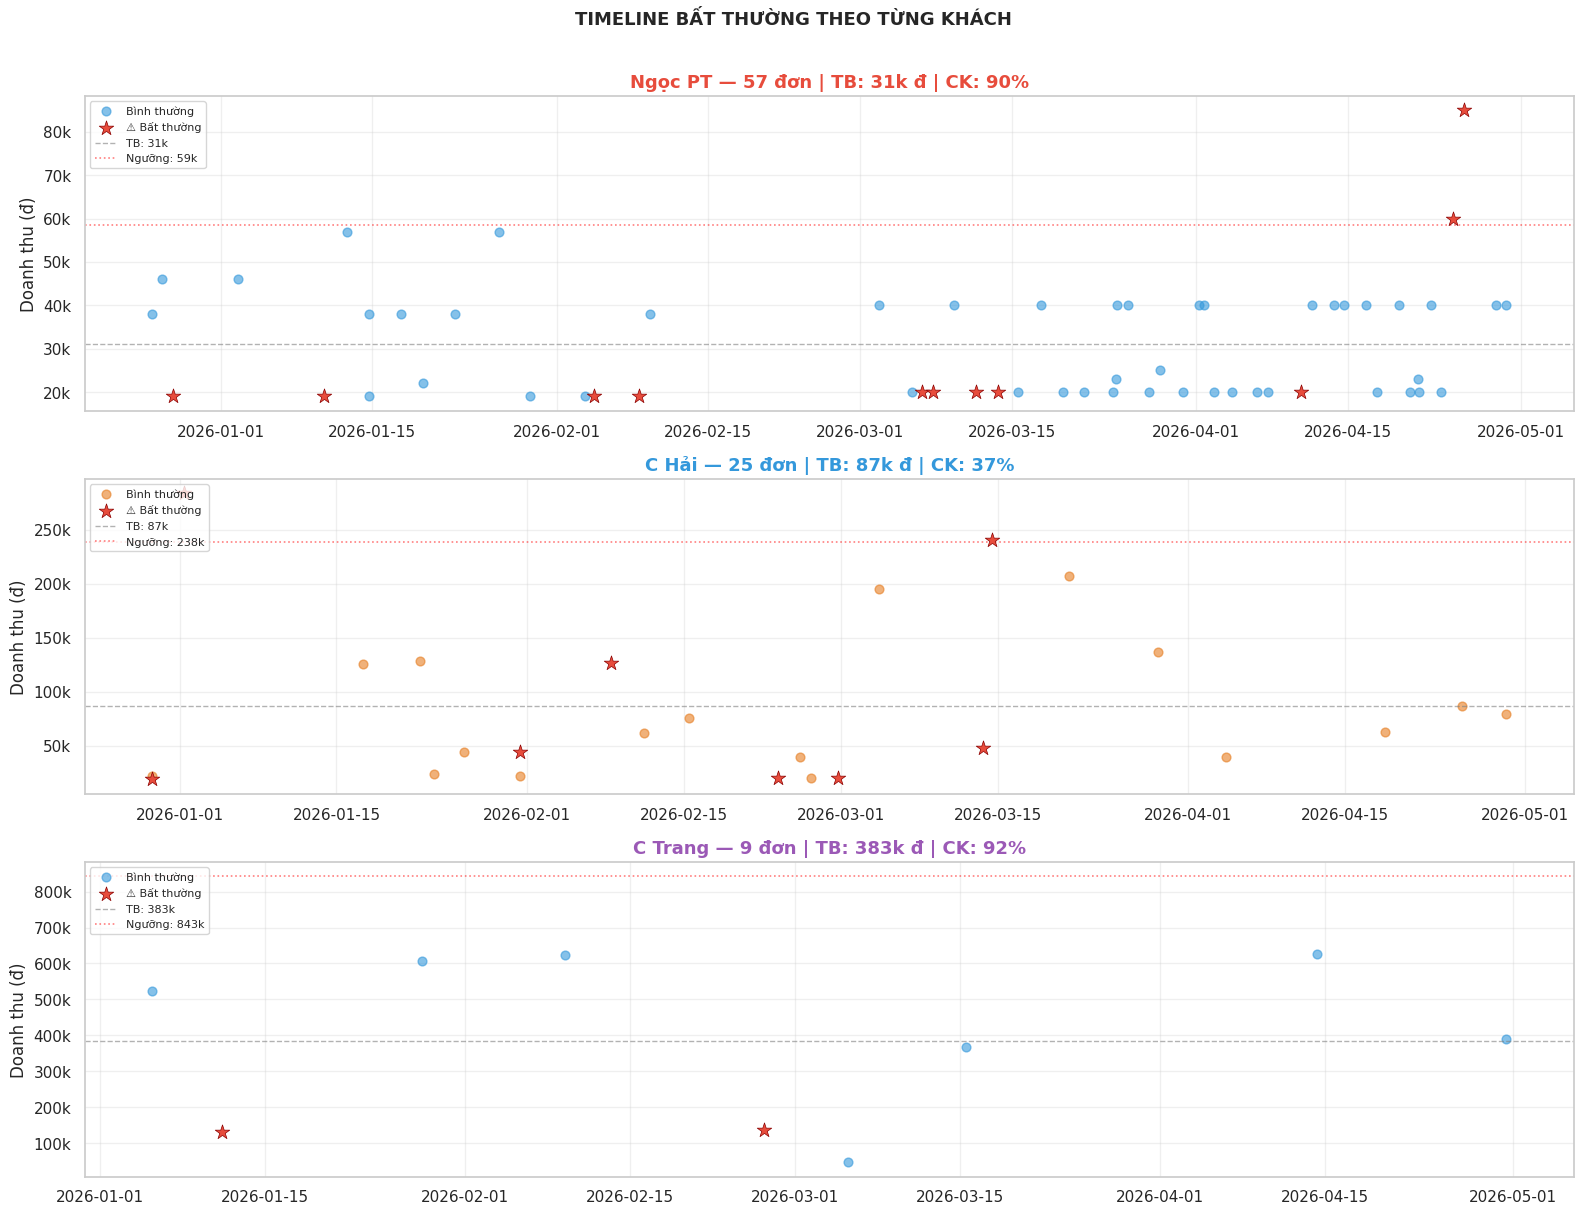

In [12]:
# ── Visualize timeline bất thường ────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for ax, (grp, label) in zip(axes, [('ngoc_pt','Ngọc PT'), ('c_hai','C Hải'), ('c_trang','C Trang')]):
    sub = notes_df[notes_df['customer_group'] == grp].sort_values('transaction_at')
    color = CUSTOMER_COLORS[grp]

    # Plot tất cả đơn
    dominant_ck = sub['transfer_payment'].sum() > sub['cash_payment'].sum()
    normal_color = '#3498db' if dominant_ck else '#e67e22'
    anomaly_color = '#e74c3c'

    avg_rev = sub['total_revenue'].mean()
    std_rev = sub['total_revenue'].std() if len(sub) > 2 else avg_rev * 0.5
    threshold_high = avg_rev + 2 * std_rev

    # Phân loại đơn
    is_payment_anomaly = (
        (dominant_ck & (sub['cash_payment'] > 0)) |
        (~dominant_ck & (sub['transfer_payment'] > 0))
    )
    is_value_anomaly = sub['total_revenue'] > threshold_high

    # Normal đơn
    normal_mask = ~(is_payment_anomaly | is_value_anomaly)
    ax.scatter(sub[normal_mask]['transaction_at'], sub[normal_mask]['total_revenue'],
               color=normal_color, alpha=0.6, s=40, label='Bình thường', zorder=2)

    # Anomaly đơn
    anom_mask = is_payment_anomaly | is_value_anomaly
    if anom_mask.any():
        ax.scatter(sub[anom_mask]['transaction_at'], sub[anom_mask]['total_revenue'],
                   color=anomaly_color, s=120, marker='*', label='⚠️ Bất thường', zorder=4, edgecolors='darkred', linewidths=0.5)

    # Đường trung bình + ngưỡng
    ax.axhline(avg_rev, color='gray', linestyle='--', alpha=0.6, linewidth=1, label=f'TB: {avg_rev/1e3:.0f}k')
    ax.axhline(threshold_high, color='red', linestyle=':', alpha=0.5, linewidth=1.2, label=f'Ngưỡng: {threshold_high/1e3:.0f}k')

    ax.set_title(f'{label} — {len(sub)} đơn | TB: {avg_rev/1e3:.0f}k đ | CK: {sub["transfer_payment"].sum()/sub["total_revenue"].sum()*100:.0f}%',
                 color=color, fontweight='bold')
    ax.set_ylabel('Doanh thu (đ)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle('TIMELINE BẤT THƯỜNG THEO TỪNG KHÁCH', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## 6. Distribution Đơn Theo Khách — Boxplot

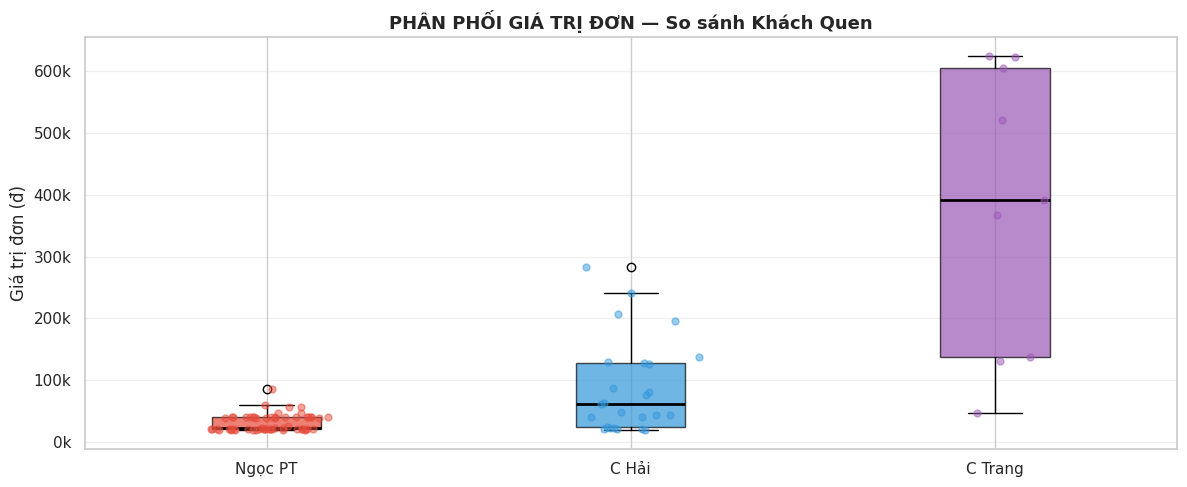

In [13]:
# ── Boxplot so sánh giá trị đơn 3 khách chính ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

top3_groups = ['ngoc_pt', 'c_hai', 'c_trang']
data_to_plot = []
labels_to_plot = []
colors_to_plot = []

for grp in top3_groups:
    sub = notes_df[notes_df['customer_group'] == grp]
    data_to_plot.append(sub['total_revenue'].values)
    labels_to_plot.append(CUSTOMER_LABELS[grp])
    colors_to_plot.append(CUSTOMER_COLORS[grp])

bp = ax.boxplot(data_to_plot, patch_artist=True, labels=labels_to_plot,
               medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], colors_to_plot):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Scatter raw points
for i, (data, color) in enumerate(zip(data_to_plot, colors_to_plot), start=1):
    jitter = np.random.normal(0, 0.08, len(data))
    ax.scatter(np.full_like(data, i, dtype=float) + jitter, data,
               alpha=0.5, s=25, color=color, zorder=3)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel('Giá trị đơn (đ)')
ax.set_title('PHÂN PHỐI GIÁ TRỊ ĐƠN — So sánh Khách Quen', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## 7. Insight Tổng hợp & Cảnh báo Rủi ro

In [14]:
# ── Summary insights ─────────────────────────────────────────────────────

print("=" * 65)
print("📊 TỔNG HỢP INSIGHT KHÁCH ĐẶC BIỆT")
print("=" * 65)

for _, row in profile[profile['customer_group'].isin(['ngoc_pt','c_hai','c_trang'])].iterrows():
    grp    = row['customer_group']
    label  = CUSTOMER_LABELS[grp]
    n      = row['so_don']
    avg    = row['don_tb']
    total  = row['doanh_thu_tong']
    pct_ck = row['pct_transfer']
    dom    = "chuyển khoản" if pct_ck >= 50 else "tiền mặt"

    print(f"\n👤 {label}")
    print(f"   → Xuất hiện {n} lần, đơn TB {avg/1e3:.0f}k đ, tổng {total/1e3:.0f}k đ")
    print(f"   → Thanh toán chủ yếu: {dom} ({pct_ck:.0f}% CK)")

    # Lấy anomaly cho khách này
    grp_anom = anom_df[anom_df['khach'] == label]
    if len(grp_anom):
        print(f"   ⚠️  {len(grp_anom)} đơn bất thường:")
        for _, a in grp_anom.iterrows():
            print(f"      [{a['ngay']}] {a['doanh_thu']/1e3:.0f}k — {a['flags']}")
    else:
        print(f"   ✅ Không có đơn bất thường đáng nghi.")

print()
print("=" * 65)
print("🔴 CẢNH BÁO RỦI RO CỤ THỂ")
print("=" * 65)

high_sev = anom_df[anom_df['severity'] >= 3].sort_values('severity', ascending=False)
if len(high_sev):
    for _, a in high_sev.iterrows():
        print(f"  [{a['severity']}★] {a['khach']} | {a['ngay']} | {a['doanh_thu']/1e3:.0f}k | {a['flags']}")
else:
    print("  Không có cảnh báo severity cao.")

print()
print("=" * 65)
print("💡 KHUYẾN NGHỊ")
print("=" * 65)
print("""
  1. NGỌC PT (90% CK): Khi xuất hiện đơn tiền mặt nhỏ lặp lại
     (~19-20k) nên kiểm tra xem có phải cùng khách hay nhầm.
     Đơn 85k ngày 25/04 là cao bất thường — cần xác nhận.

  2. C HẢI (63% tiền mặt, đơn lớn): Đơn 284k ngày 01/01 thanh
     toán CK — bất thường với người quen dùng tiền mặt và đơn
     lớn. Cần đối chiếu lại có nhận đủ CK chưa.

  3. C TRANG (92% CK, đơn rất lớn ~383k TB): Hai đơn tiền mặt
     131k và 137k cần xác nhận két nhận đủ. Đây là khách có
     tổng chi tiêu cao nhất (3.4M trong 9 lần) — quan hệ VIP.

  4. Ghi chú "c trang + 20k tiền mặt mượn": Quán đã cho C Trang
     mượn tiền mặt 20k — nên theo dõi xem đã hoàn chưa.
""")


📊 TỔNG HỢP INSIGHT KHÁCH ĐẶC BIỆT

👤 Ngọc PT
   → Xuất hiện 57 lần, đơn TB 31k đ, tổng 1767k đ
   → Thanh toán chủ yếu: chuyển khoản (90% CK)
   ⚠️  11 đơn bất thường:
      [2026-04-25 18:02] 85k — 📈 Đơn cao bất thường (85k vs TB 31k, ngưỡng 59k)
      [2026-04-24 16:39] 60k — 📈 Đơn cao bất thường (60k vs TB 31k, ngưỡng 59k)
      [2026-03-06 16:28] 20k — 💸 CK→Tiền mặt (khách 90% CK thói quen)
      [2026-03-07 17:04] 20k — 💸 CK→Tiền mặt (khách 90% CK thói quen)
      [2026-03-11 16:38] 20k — 💸 CK→Tiền mặt (khách 90% CK thói quen)
      [2026-03-13 16:42] 20k — 💸 CK→Tiền mặt (khách 90% CK thói quen)
      [2026-04-10 16:07] 20k — 💸 CK→Tiền mặt (khách 90% CK thói quen)
      [2025-12-27 14:48] 19k — 💸 CK→Tiền mặt (khách 90% CK thói quen)
      [2026-01-10 13:15] 19k — 💸 CK→Tiền mặt (khách 90% CK thói quen)
      [2026-02-04 11:07] 19k — 💸 CK→Tiền mặt (khách 90% CK thói quen)
      [2026-02-08 13:53] 19k — 💸 CK→Tiền mặt (khách 90% CK thói quen)

👤 C Hải
   → Xuất hiện 25 lần, đơn TB 87k

---
## 8. Xuất Dữ liệu

In [15]:
# ── Xuất customer pattern data ───────────────────────────────────────────

# Bổ sung label & norm vào full notes data
notes_export = notes_df[[
    'transaction_at','total_revenue','cash_payment','transfer_payment',
    'notes','norm_note','customer_group'
]].copy()
notes_export['customer_label'] = notes_export['customer_group'].map(CUSTOMER_LABELS)

notes_export.to_csv('./data/Customer_Pattern.csv', index=False)
print(f"✅ Đã xuất: data/Customer_Pattern.csv ({len(notes_export)} dòng)")

# Summary table
print("\n📊 BẢNG TÓM TẮT KHÁCH:")
display(profile[['label','so_don','don_tb','don_max','doanh_thu_tong','pct_transfer']].rename(columns={
    'label': 'Khách',
    'so_don': 'Số đơn',
    'don_tb': 'ĐTB (đ)',
    'don_max': 'Max (đ)',
    'doanh_thu_tong': 'Tổng DT (đ)',
    'pct_transfer': '% CK',
}).reset_index(drop=True))


✅ Đã xuất: data/Customer_Pattern.csv (101 dòng)

📊 BẢNG TÓM TẮT KHÁCH:


,Khách,Số đơn,ĐTB (đ),Max (đ),Tổng DT (đ),% CK
0,Ngọc PT,57,31000.0,85000,1767000,90.0
1,C Hải,25,87080.0,284000,2177000,36.9
2,C Trang,9,383111.0,625000,3448000,92.2
3,Khác / 1 lần,7,24857.0,45000,174000,61.5
4,Bạn Chú Thọ,2,52000.0,85000,104000,0.0
5,Ông Chú SH,1,52000.0,52000,52000,0.0
